In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
import xgboost as xgb
import joblib
import os

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [2]:
train = pd.read_csv('../data/processed/train_features.csv')
test = pd.read_csv('../data/processed/test_features.csv')
test_labels = pd.read_csv('../data/processed/test_rul_labels.csv')
feature_cols = joblib.load('../models/feature_cols.pkl')

print(f"Train: {train.shape}")
print(f"Test: {test.shape}")
print(f"Features: {len(feature_cols)}")

Train: (20631, 101)
Test: (13096, 100)
Features: 98


In [3]:
X = train[feature_cols]
y = train['RUL']
groups = train['engine_id']

# Split by engine, not by row
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(splitter.split(X, y, groups))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

print(f"Training rows: {X_train.shape[0]}")
print(f"Validation rows: {X_val.shape[0]}")
print(f"Training engines: {train['engine_id'].iloc[train_idx].nunique()}")
print(f"Validation engines: {train['engine_id'].iloc[val_idx].nunique()}")

Training rows: 16561
Validation rows: 4070
Training engines: 80
Validation engines: 20


In [4]:
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print("Training complete.")

[0]	validation_0-rmse:40.01245
[50]	validation_0-rmse:15.09540
[100]	validation_0-rmse:14.22758
[150]	validation_0-rmse:14.05689
[200]	validation_0-rmse:13.93232
[250]	validation_0-rmse:13.90398
[299]	validation_0-rmse:13.87789
Training complete.


Validation RMSE: 13.86 cycles


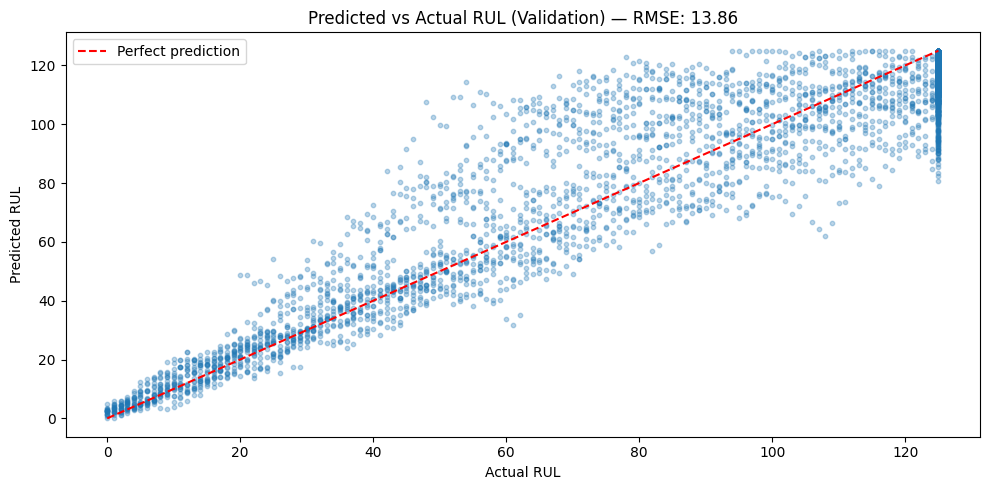

In [5]:
val_predictions = model.predict(X_val)

# Clip predictions - RUL can't be negative
val_predictions = np.clip(val_predictions, 0, 125)

rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
print(f"Validation RMSE: {rmse:.2f} cycles")

# Plot predicted vs actual
plt.figure(figsize=(10, 5))
plt.scatter(y_val, val_predictions, alpha=0.3, s=10)
plt.plot([0, 125], [0, 125], 'r--', label='Perfect prediction')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title(f'Predicted vs Actual RUL (Validation) — RMSE: {rmse:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

Test RMSE: 16.24 cycles


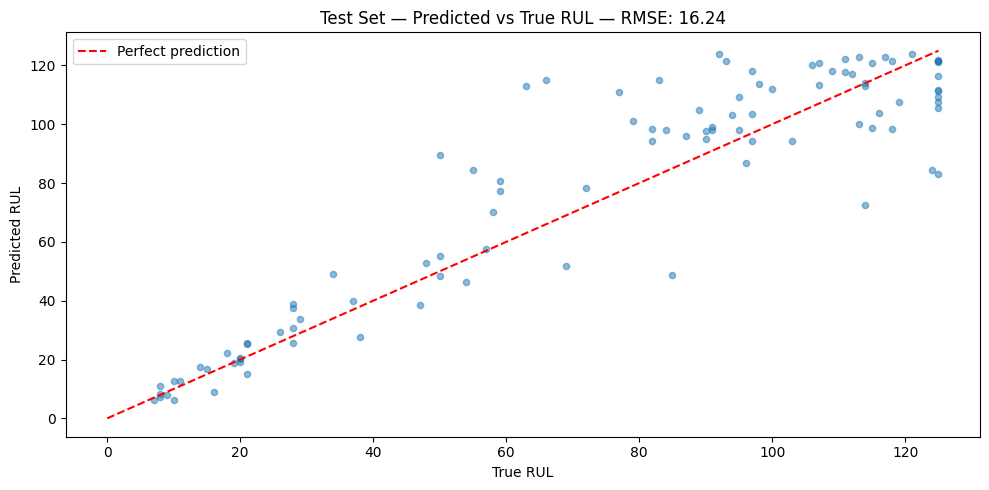

In [6]:
# Get the last cycle of each test engine - that's the prediction point
test_last = test.groupby('engine_id').last().reset_index()
X_test = test_last[feature_cols]

# Predict
test_predictions = model.predict(X_test)
test_predictions = np.clip(test_predictions, 0, 125)

# Compare against true RUL
true_rul = test_labels['true_RUL'].values

# Cap true RUL at 125 for fair comparison
true_rul_capped = np.clip(true_rul, 0, 125)

test_rmse = np.sqrt(mean_squared_error(true_rul_capped, test_predictions))
print(f"Test RMSE: {test_rmse:.2f} cycles")

# Plot
plt.figure(figsize=(10, 5))
plt.scatter(true_rul_capped, test_predictions, alpha=0.5, s=20)
plt.plot([0, 125], [0, 125], 'r--', label='Perfect prediction')
plt.xlabel('True RUL')
plt.ylabel('Predicted RUL')
plt.title(f'Test Set — Predicted vs True RUL — RMSE: {test_rmse:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

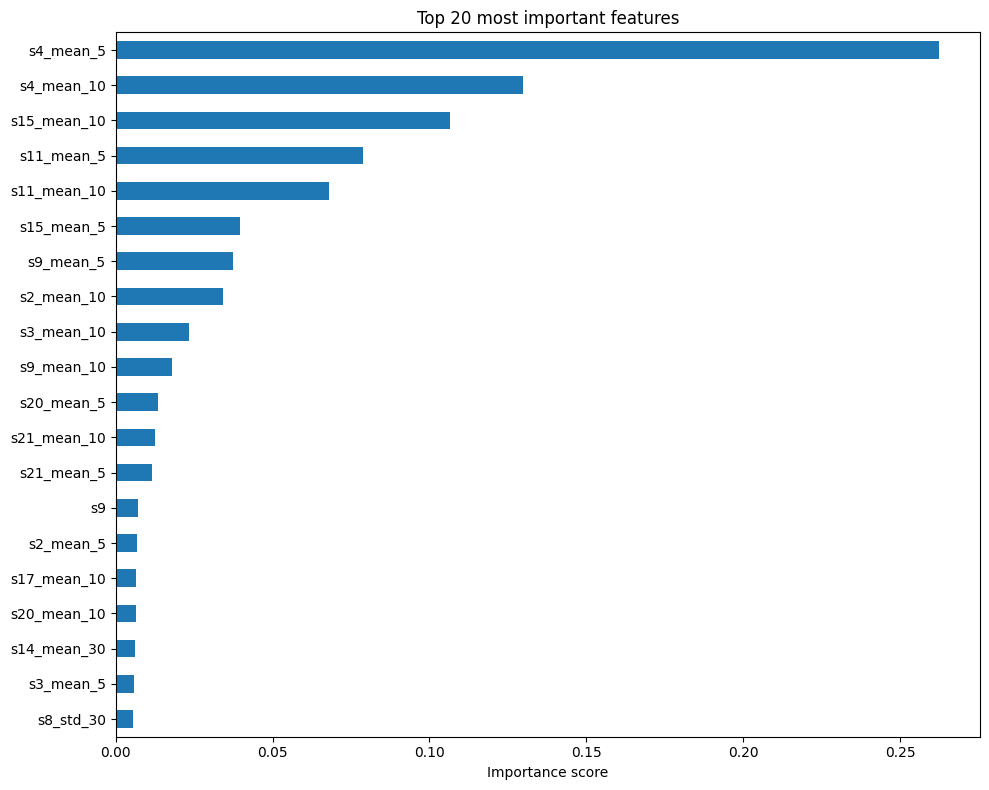

Top 10 features:
s4_mean_5      0.262285
s4_mean_10     0.129645
s15_mean_10    0.106659
s11_mean_5     0.078978
s11_mean_10    0.067904
s15_mean_5     0.039642
s9_mean_5      0.037252
s2_mean_10     0.034069
s3_mean_10     0.023513
s9_mean_10     0.017981
dtype: float32


In [7]:
importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

# Top 20
plt.figure(figsize=(10, 8))
importance.head(20).plot(kind='barh')
plt.title('Top 20 most important features')
plt.xlabel('Importance score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importance.head(10))

In [8]:
os.makedirs('../models', exist_ok=True)

joblib.dump(model, '../models/xgb_model.pkl')
joblib.dump(feature_cols, '../models/feature_cols.pkl')

print("Saved:")
print("  models/xgb_model.pkl")
print("  models/feature_cols.pkl")

Saved:
  models/xgb_model.pkl
  models/feature_cols.pkl


In [9]:
def predict_rul(sensor_readings_df):
    """
    Takes a dataframe of sensor readings for one engine
    (multiple cycles, in order) and returns the predicted
    RUL at the latest cycle along with a risk classification.
    
    sensor_readings_df: raw sensor readings, same columns as raw data
    Returns: dict with predicted_rul, risk_level, confidence
    """
    scaler = joblib.load('../models/scaler.pkl')
    model = joblib.load('../models/xgb_model.pkl')
    feature_cols = joblib.load('../models/feature_cols.pkl')
    
    # Apply same feature engineering as training
    # (In the real app this will call your features.py functions)
    # For now just confirm the shape is right
    
    return {
        'predicted_rul': None,  # placeholder
        'risk_level': None,
        'confidence': None
    }

print("predict_rul function defined.")
print("Will be fully implemented in src/model.py next.")

predict_rul function defined.
Will be fully implemented in src/model.py next.


## Results Summary

| Metric | Value |
|--------|-------|
| Validation RMSE | 13.86 cycles |
| Test RMSE | 16.24 cycles |
| Top predictor | s4_mean_5 (LPT outlet temperature, 5-cycle rolling mean) |
| Dataset | NASA CMAPSS FD001 |
| Model | XGBoost Regressor (300 estimators, lr=0.05) |

A test RMSE of 16.24 cycles against a failure warning window of 
30-40 cycles means the model provides roughly half a warning window 
of advance notice — enough for a maintenance team to order parts 
and schedule a technician before an unplanned failure occurs.